# Linear Regression on Kaggle's Car Dataset

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
# import dataset
df = pd.read_csv('../datasets/cardataset.csv')
df.sample(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
5248,Hyundai,Genesis Coupe,2014,premium unleaded (recommended),274.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Midsize,Coupe,27,19,1439,27200
4796,Ford,Focus,2017,flex-fuel (unleaded/E85),160.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Flex Fuel,Compact,Sedan,40,27,5657,23575
11279,Toyota,Venza,2014,regular unleaded,268.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Performance",Midsize,Wagon,25,18,2031,39570
5782,Infiniti,I30,1999,regular unleaded,190.0,6.0,MANUAL,front wheel drive,4.0,"Luxury,Performance",Midsize,Sedan,24,19,190,2433
8445,Buick,Reatta,1991,regular unleaded,170.0,6.0,AUTOMATIC,front wheel drive,2.0,NaN,Compact,Coupe,25,16,155,2000


## Exploratory Data Analysis

In [128]:
# number of rows in the dataset
len(df)

11914

In [129]:
# lowercase all column names, and replace space in column names with underscore
df.columns = df.columns.str.lower().str.replace(" ","_")

In [130]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [131]:
# Find columns with text values
string_columns = list(df.select_dtypes(include=['object']).columns)
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(" ","_")

C:\Users\gupta\AppData\Local\Temp\ipykernel_8700\3511654387.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_columns = list(df.select_dtypes(include=['object']).columns)


In [132]:
df.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [133]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### Handling Null Values
- Option 1: Drop all rows with `NaN` using `df.dropna()`.
- Option 2: **Imputation**: Here, we replace missing data with statistical estimates for numerical datatypes. 

For categorical datatypes, we can either use Mode, or replace missing values with "Unknown" or "Missing". This is often the best choice for machine learning because the model can learn that the absence of data is a signal itself.
If number of missing values is very small (less than 1% of data), we can remove those rows.

In [155]:
# remove rows where engine_hp, engine_cylinders, engine_fuel_type values are missing: these are less than 1%
df = df.dropna(subset=['engine_hp','engine_cylinders', 'engine_fuel_type'])
# In market_category, replace missing values with "Unknown"
df['market_category'] = df['market_category'].fillna('Unknown')
df.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
market_category      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

### Analyze Target Variable

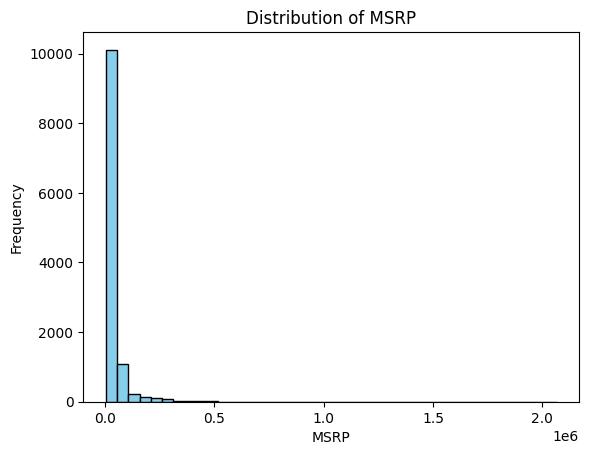

In [135]:
# Analyze target variable: MSRP
plt.hist(df['msrp'], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.title('Distribution of MSRP')
plt.show()

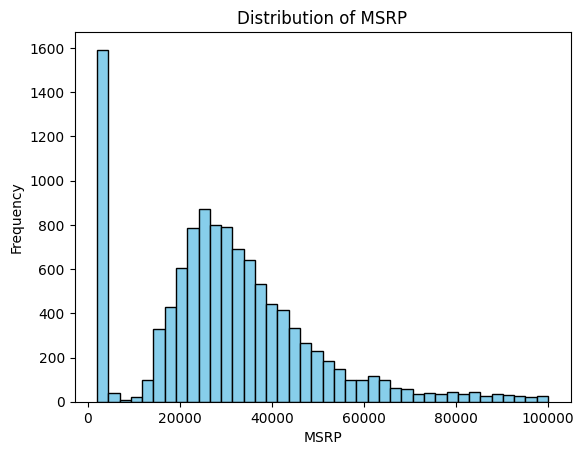

In [136]:
# lot of cars with low prices, and a very long tail
# lets view zoom-in
plt.hist(df.msrp[df.msrp < 100000], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.title('Distribution of MSRP')
plt.show()

### Remove outliers from MSRP

In [137]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['msrp'].quantile(0.25)
Q3 = df['msrp'].quantile(0.75)
IQR = Q3 - Q1

# Define the cutoffs
lower_cutoff = Q1 - 1.5 * IQR
upper_cutoff = Q3 + 1.5 * IQR
print(upper_cutoff)
df = df[df['msrp'] <= upper_cutoff]

74065.0


## Setup Validation Framework

In [138]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['msrp'])
# log transformation to address long tail of target variable distribution
y_log = np.log1p(df['msrp'])

X_train, X_test, y_train_log, y_test_log = train_test_split(X,y_log, test_size=0.2, random_state=42)

In [139]:
# view shape of train and test datasets
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train_log.shape}, y_test: {y_test_log.shape}')

X_train: (8664, 15), X_test: (2166, 15), y_train: (8664,), y_test: (2166,)


## One-Hot Encoding

In [140]:
# Initialize one-hot encoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [141]:
X_train_encoded_raw = encoder.fit_transform(X_train[string_columns])
X_test_encoded_raw = encoder.transform(X_test[string_columns])

In [142]:
# get new feature names
encoded_col_names = encoder.get_feature_names_out(string_columns)

In [143]:
X_train_encoded_df = pd.DataFrame(X_train_encoded_raw, columns=encoded_col_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded_raw, columns=encoded_col_names,index=X_test.index)

In [144]:
# rejoin and delete originals
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()
X_train_final = pd.concat([X_train[numeric_cols], X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test[numeric_cols], X_test_encoded_df], axis=1)

## Train Linear Regression Model

In [145]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train_final,y_train_log)
coef = regressor.coef_
intercept = regressor.intercept_

## Make Predictions

In [146]:
y_pred_log = regressor.predict(X_test_final)

# undo log transformation
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test_log)

## Evaluate the model

### Residual Plot

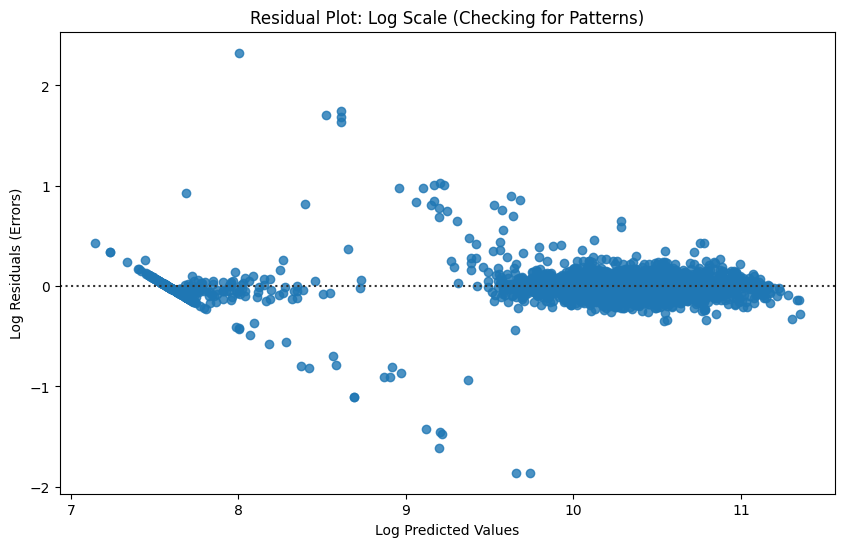

In [147]:
# Residual Plot-

# 1. Calculate residuals on the LOG scale
log_residuals = y_test_log - y_pred_log
import seaborn as sns
# 2. Residual Plot on Log Scale
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred_log, y=log_residuals, line_kws={'color': 'red'})
plt.xlabel('Log Predicted Values')
plt.ylabel('Log Residuals (Errors)')
plt.title('Residual Plot: Log Scale (Checking for Patterns)')
plt.show()

### Distribution of Residuals on Log Scale

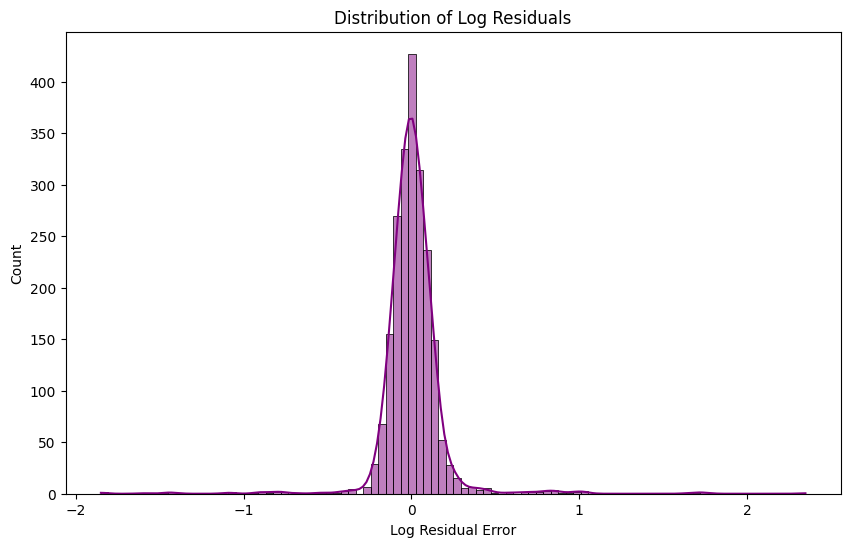

In [148]:
# 3. Distribution of Residuals on Log Scale
plt.figure(figsize=(10, 6))
sns.histplot(log_residuals, kde=True, color='purple')
plt.title('Distribution of Log Residuals')
plt.xlabel('Log Residual Error')
plt.show()

### Make Predictions

In [149]:
# --- STEP 1: Make Predictions (Model output is on the LOG scale) ---
y_pred_log = regressor.predict(X_test_final)

# --- STEP 2: Undo Log Transformation to get actual Dollar amounts ---
y_pred_dollars = np.expm1(y_pred_log)

# --- STEP 3: (Optional) Compare with actual values in Dollars ---
y_test_dollars = np.expm1(y_test_log)

# Display a sample of the results
results = pd.DataFrame({
    'Actual_MSRP': y_test_dollars,
    'Predicted_MSRP': y_pred_dollars
})
print(results.head())

       Actual_MSRP  Predicted_MSRP
33         24995.0    27842.800315
9474       31665.0    30009.360655
7139        2000.0     2106.579101
10682      28215.0    27705.169574
6225       27230.0    26755.676027


### Plot Predicted vs Actual in original scale

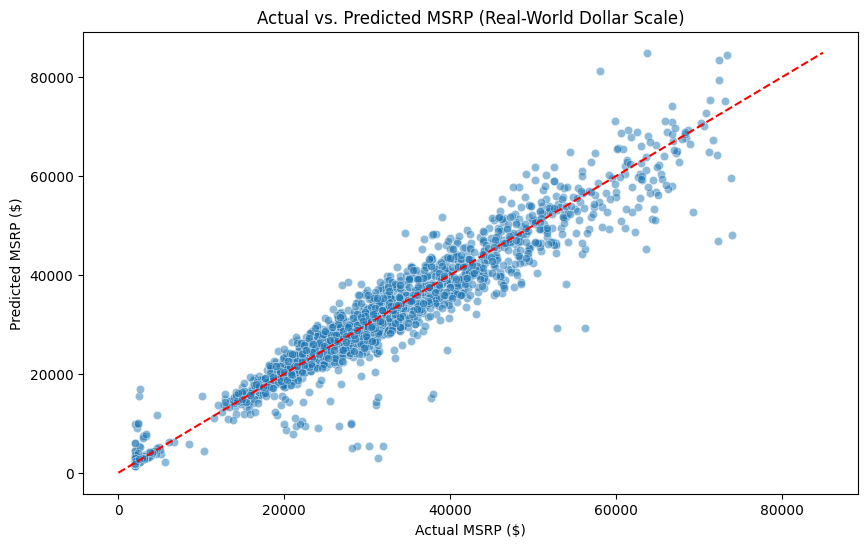

In [150]:
#Actual vs. Predicted Plot (Original Dollar Scale)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5)

# Add the "Perfect Prediction" line
max_val = max(y_test_original.max(), y_pred_original.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')

plt.xlabel('Actual MSRP ($)')
plt.ylabel('Predicted MSRP ($)')
plt.title('Actual vs. Predicted MSRP (Real-World Dollar Scale)')
plt.show()

## R2 Score

In [151]:
from sklearn.metrics import r2_score

# Calculate R2 on the log scale
r2_log = r2_score(y_test_log, y_pred_log)

print(f"R2 Score (Log Scale): {r2_log:.4f}")

R2 Score (Log Scale): 0.9611


In [152]:
# Calculate R2 on the original dollar scale
r2_original = r2_score(y_test_original, y_pred_original)

print(f"R2 Score (Dollar Scale): {r2_original:.4f}")

R2 Score (Dollar Scale): 0.9354


In [153]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Original Scale Metrics
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

print("--- Final Model Performance (Original Dollars) ---")
print(f"R2 Score: {r2_original:.4f}")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")

--- Final Model Performance (Original Dollars) ---
R2 Score: 0.9354
Mean Absolute Error: $2,541.76
Root Mean Squared Error: $4,024.21


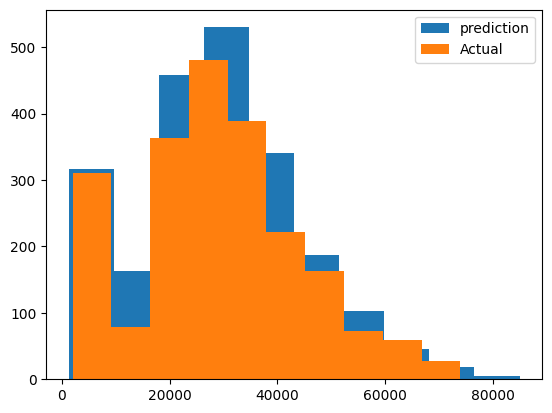

In [154]:
# distribution of predicted and actual values
plt.hist(y_pred_dollars, label='prediction')
plt.hist(y_test_dollars, label='Actual')
plt.legend()
plt.show()